# 实验名称
### 研究动机
- 在传统机器学习中，普遍认为模型拟合能力远大于数据集的参数空间规模时，模型会产生严重的过拟合现象。然而随着深度学习的发展，一种普遍的现象却展现出了与之相反的现实：随着大模型的不断发展，大量实验证明复杂的深度学习模型并不会对数据产生过拟合现象，反而展现出名为"涌现"的能力。因此，在阅读相关书籍了解到深度学习目前常用的研究手段为"现象驱动的理论研究"后，作者想通过控制变量实践来研究在基础视觉数据集上究竟是小参数空间配上多信息量数据集的情况还是大参数空间配上少信息量数据集的情况下模型的性能最佳。

### 预实验设计
- 近年来为了解决深度学习模型黑盒的问题，一种研究方式为"先利用人造数据拆解神经网络'黑盒子'的规律和偏好，再利用神经网络的规律和偏好解析真实数据"黑盒子"的结构。我认为其一种可能性在于人类无法拆解上亿参数规模的大模型进行因果分析，但从简单的数据集(包括人造数据集上)可以通过数学/统计学实验发现神经网络的一些隐式偏好(也称隐式正则化)，并从中获得启发带入到大模型实验当中。

- 因此，为从低维度探究我们的实验主题，我们通过构建一个复杂的多项式，

# 阶段一：双重下降（Double Descent）Toy Model

### 研究动机
- 验证「参数量跨越插值临界点」时测试误差先降、爆峰、再降的经典双重下降现象。
- 用**无正则化全批量梯度下降**（非 `np.polyfit` 解析解）拟合，观察优化器的**隐式偏置**（趋向最小 $L_2$ 范数插值解）。

### 实验设定
| 项目 | 取值 |
|------|------|
| 目标函数 | $f(x)=\sin(2\pi x)+0.5\cos(5\pi x)$ |
| 训练样本 | $N=30$，$x\sim\mathrm{Unif}(0,1)$ |
| 噪声 | $y_{\mathrm{train}}=f(x)+\epsilon,\ \epsilon\sim\mathcal{N}(0,\sigma^2)$ |
| 模型 | $D$ 阶多项式，参数量 $P=D+1$ |
| $D$ 扫描 | $1 \to 100$ |
| 求解器 | Vanilla GD，随机/零初始化，**禁止**最小二乘解析解 |

> **临界点**：爆峰出现在 $P\approx N$（即 $D\approx N-1$），而非 $D\approx N$。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

# 固定超参
N_TRAIN = 30
SIGMA = 0.3          # 噪声标准差
D_MAX = 100
N_TEST = 1000
GD_MAX_ITERS = 80_000
GD_TOL = 1e-9

In [2]:
def target_fn(x: np.ndarray) -> np.ndarray:
    """复杂基准函数（非多项式，避免与模型同族）。"""
    return np.sin(2 * np.pi * x) + 0.5 * np.cos(5 * np.pi * x)

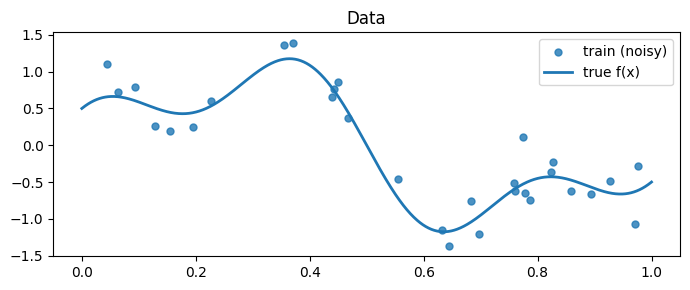

In [3]:
# Step 1: 生成带噪训练集 + 干净测试集
x_train = rng.uniform(0.0, 1.0, size=N_TRAIN)
y_clean_train = target_fn(x_train)
y_train = y_clean_train + rng.normal(0.0, SIGMA, size=N_TRAIN)

x_test = np.linspace(0.0, 1.0, N_TEST)
y_test = target_fn(x_test)  # 测试集不加噪

plt.figure(figsize=(7, 3))
plt.scatter(x_train, y_train, s=25, label="train (noisy)", alpha=0.8)
plt.plot(x_test, y_test, lw=2, label="true f(x)")
plt.legend(); plt.title("Data"); plt.tight_layout()

In [4]:
# Step 2: 多项式特征 + 列标准化（改善 GD 条件数，不引入显式正则）
def poly_features(x: np.ndarray, degree: int) -> np.ndarray:
  """返回形状 (len(x), degree+1) 的设计矩阵 [1, x, x^2, ..., x^degree]。"""
  return np.vstack([x ** k for k in range(degree + 1)]).T


def standardize_fit_transform(phi: np.ndarray):
  mu = phi.mean(axis=0)
  std = phi.std(axis=0)
  std = np.where(std < 1e-12, 1.0, std)
  return (phi - mu) / std, mu, std


def standardize_transform(phi: np.ndarray, mu: np.ndarray, std: np.ndarray):
  std = np.where(std < 1e-12, 1.0, std)
  return (phi - mu) / std

In [5]:
# Step 3: 无正则化 Vanilla GD（严禁 polyfit / 正规方程）
def vanilla_gd(
    phi: np.ndarray,
    y: np.ndarray,
    lr: float,
    max_iters: int = GD_MAX_ITERS,
    tol: float = GD_TOL,
    w0: np.ndarray | None = None,
):
  n, p = phi.shape
  w = np.zeros(p) if w0 is None else w0.copy()
  prev_loss = np.inf
  for _ in range(max_iters):
    residual = phi @ w - y
    grad = (2.0 / n) * (phi.T @ residual)
    w -= lr * grad
    loss = np.mean(residual ** 2)
    if abs(prev_loss - loss) < tol:
      break
    prev_loss = loss
  return w


def pick_lr(phi: np.ndarray, y: np.ndarray, candidates=(1e-4, 3e-4, 1e-3, 3e-3, 1e-2)):
  """粗网格选学习率：取训练 MSE 最低的 lr。"""
  best_lr, best_loss, best_w = candidates[0], np.inf, None
  for lr in candidates:
    w = vanilla_gd(phi, y, lr=lr, max_iters=20_000)
    loss = np.mean((phi @ w - y) ** 2)
    if loss < best_loss:
      best_lr, best_loss, best_w = lr, loss, w
  return best_lr

In [6]:
# Step 4: 扫描 D=1..D_MAX，记录测试 MSE
degrees = np.arange(1, D_MAX + 1)
test_mse = np.empty(len(degrees))
train_mse = np.empty(len(degrees))

for i, d in enumerate(degrees):
  phi_tr = poly_features(x_train, d)
  phi_tr, mu, std = standardize_fit_transform(phi_tr)
  phi_te = standardize_transform(poly_features(x_test, d), mu, std)

  lr = pick_lr(phi_tr, y_train)
  # 零初始化：过参数化区间更接近「最小范数」隐式偏置
  w = vanilla_gd(phi_tr, y_train, lr=lr)

  train_mse[i] = np.mean((phi_tr @ w - y_train) ** 2)
  test_mse[i] = np.mean((phi_te @ w - y_test) ** 2)

print(f"D={degrees[np.argmin(test_mse)]} 时测试 MSE 最低: {test_mse.min():.4f}")

D=21 时测试 MSE 最低: 0.1055


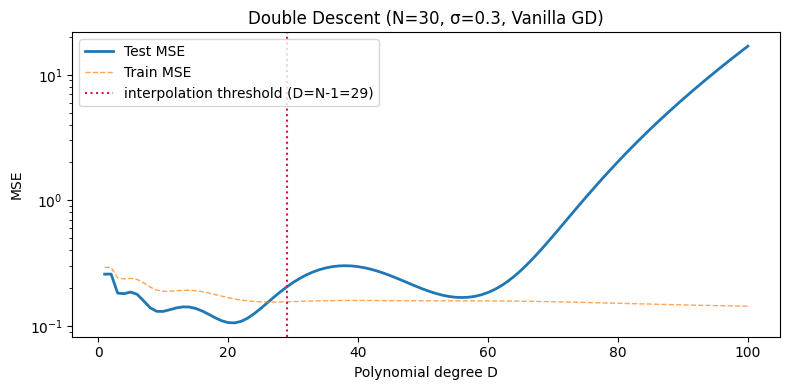

In [7]:
# Step 5: 绘制双重下降曲线
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(degrees, test_mse, lw=2, label="Test MSE")
ax.plot(degrees, train_mse, lw=1, ls="--", alpha=0.7, label="Train MSE")
ax.axvline(N_TRAIN - 1, color="crimson", ls=":", lw=1.5,
           label=f"interpolation threshold (D=N-1={N_TRAIN-1})")
ax.set_xlabel("Polynomial degree D")
ax.set_ylabel("MSE")
ax.set_title(f"Double Descent (N={N_TRAIN}, σ={SIGMA}, Vanilla GD)")
ax.legend(); ax.set_yscale("log"); plt.tight_layout()